In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Clean_Dataset.csv')
print(df.head())

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [4]:
# Borramos las columnas que no aportan valor
df = df.drop(['Unnamed: 0'], axis=1)

In [5]:
# Borramos las columnas que no aportan valor 
# Unnamed: 0 es un índice y flight tiene demasiados valores únicos
# df = df.drop(['Unnamed: 0', 'flight'], axis=1)

In [6]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [7]:
# Calculate the correlation matrix using only numeric columns
df_numeric = df.select_dtypes(include=['number'])
df_numeric.corr().T

,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


In [8]:
df1=df.groupby(['flight','airline'],as_index=False).count()
df1.airline.value_counts()

airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64

Podemos observar que Indigo es la aerolínea más popular

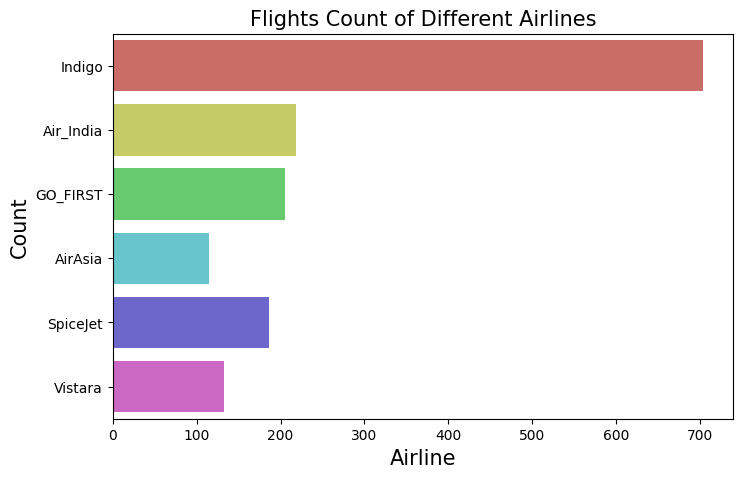

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(df1['airline'],palette='hls')
plt.title('Flights Count of Different Airlines',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

In [10]:
df2=df.groupby(['flight','airline','class'],as_index=False).count()
df2['class'].value_counts()

class
Economy     1560
Business     295
Name: count, dtype: int64

Podemos observar que Economy es la clase más común

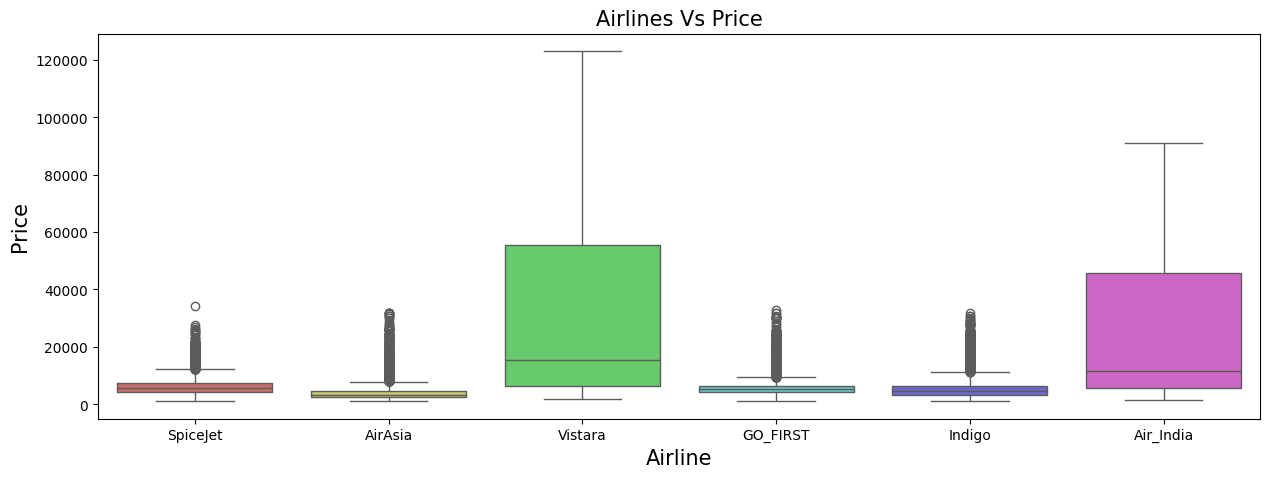

In [11]:
plt.figure(figsize=(15,5))
sns.boxplot(x=df['airline'],y=df['price'],palette='hls')
plt.title('Airlines Vs Price',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

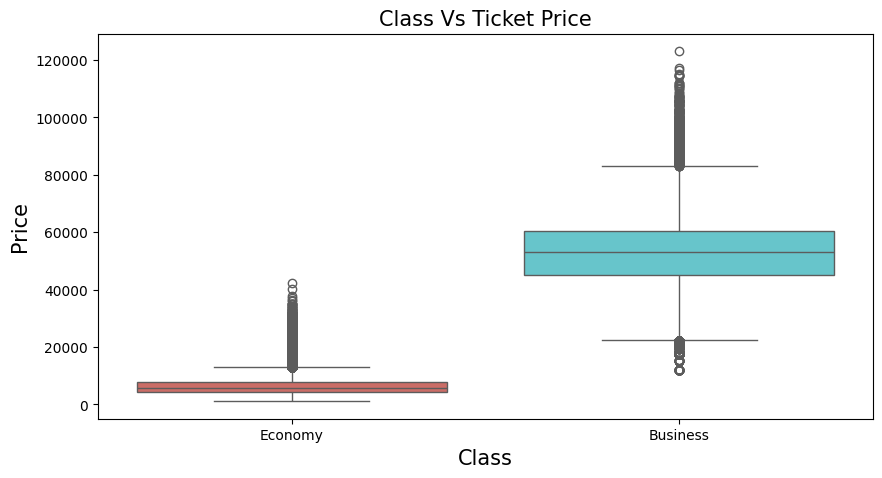

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x='class',y='price',data=df,palette='hls')
plt.title('Class Vs Ticket Price',fontsize=15)
plt.xlabel('Class',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

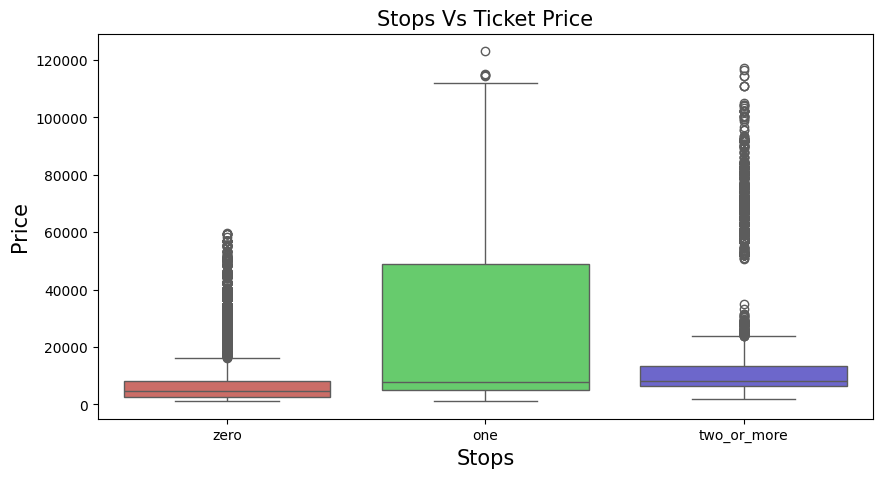

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x='stops',y='price',data=df,palette='hls')
plt.title('Stops Vs Ticket Price',fontsize=15)
plt.xlabel('Stops',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

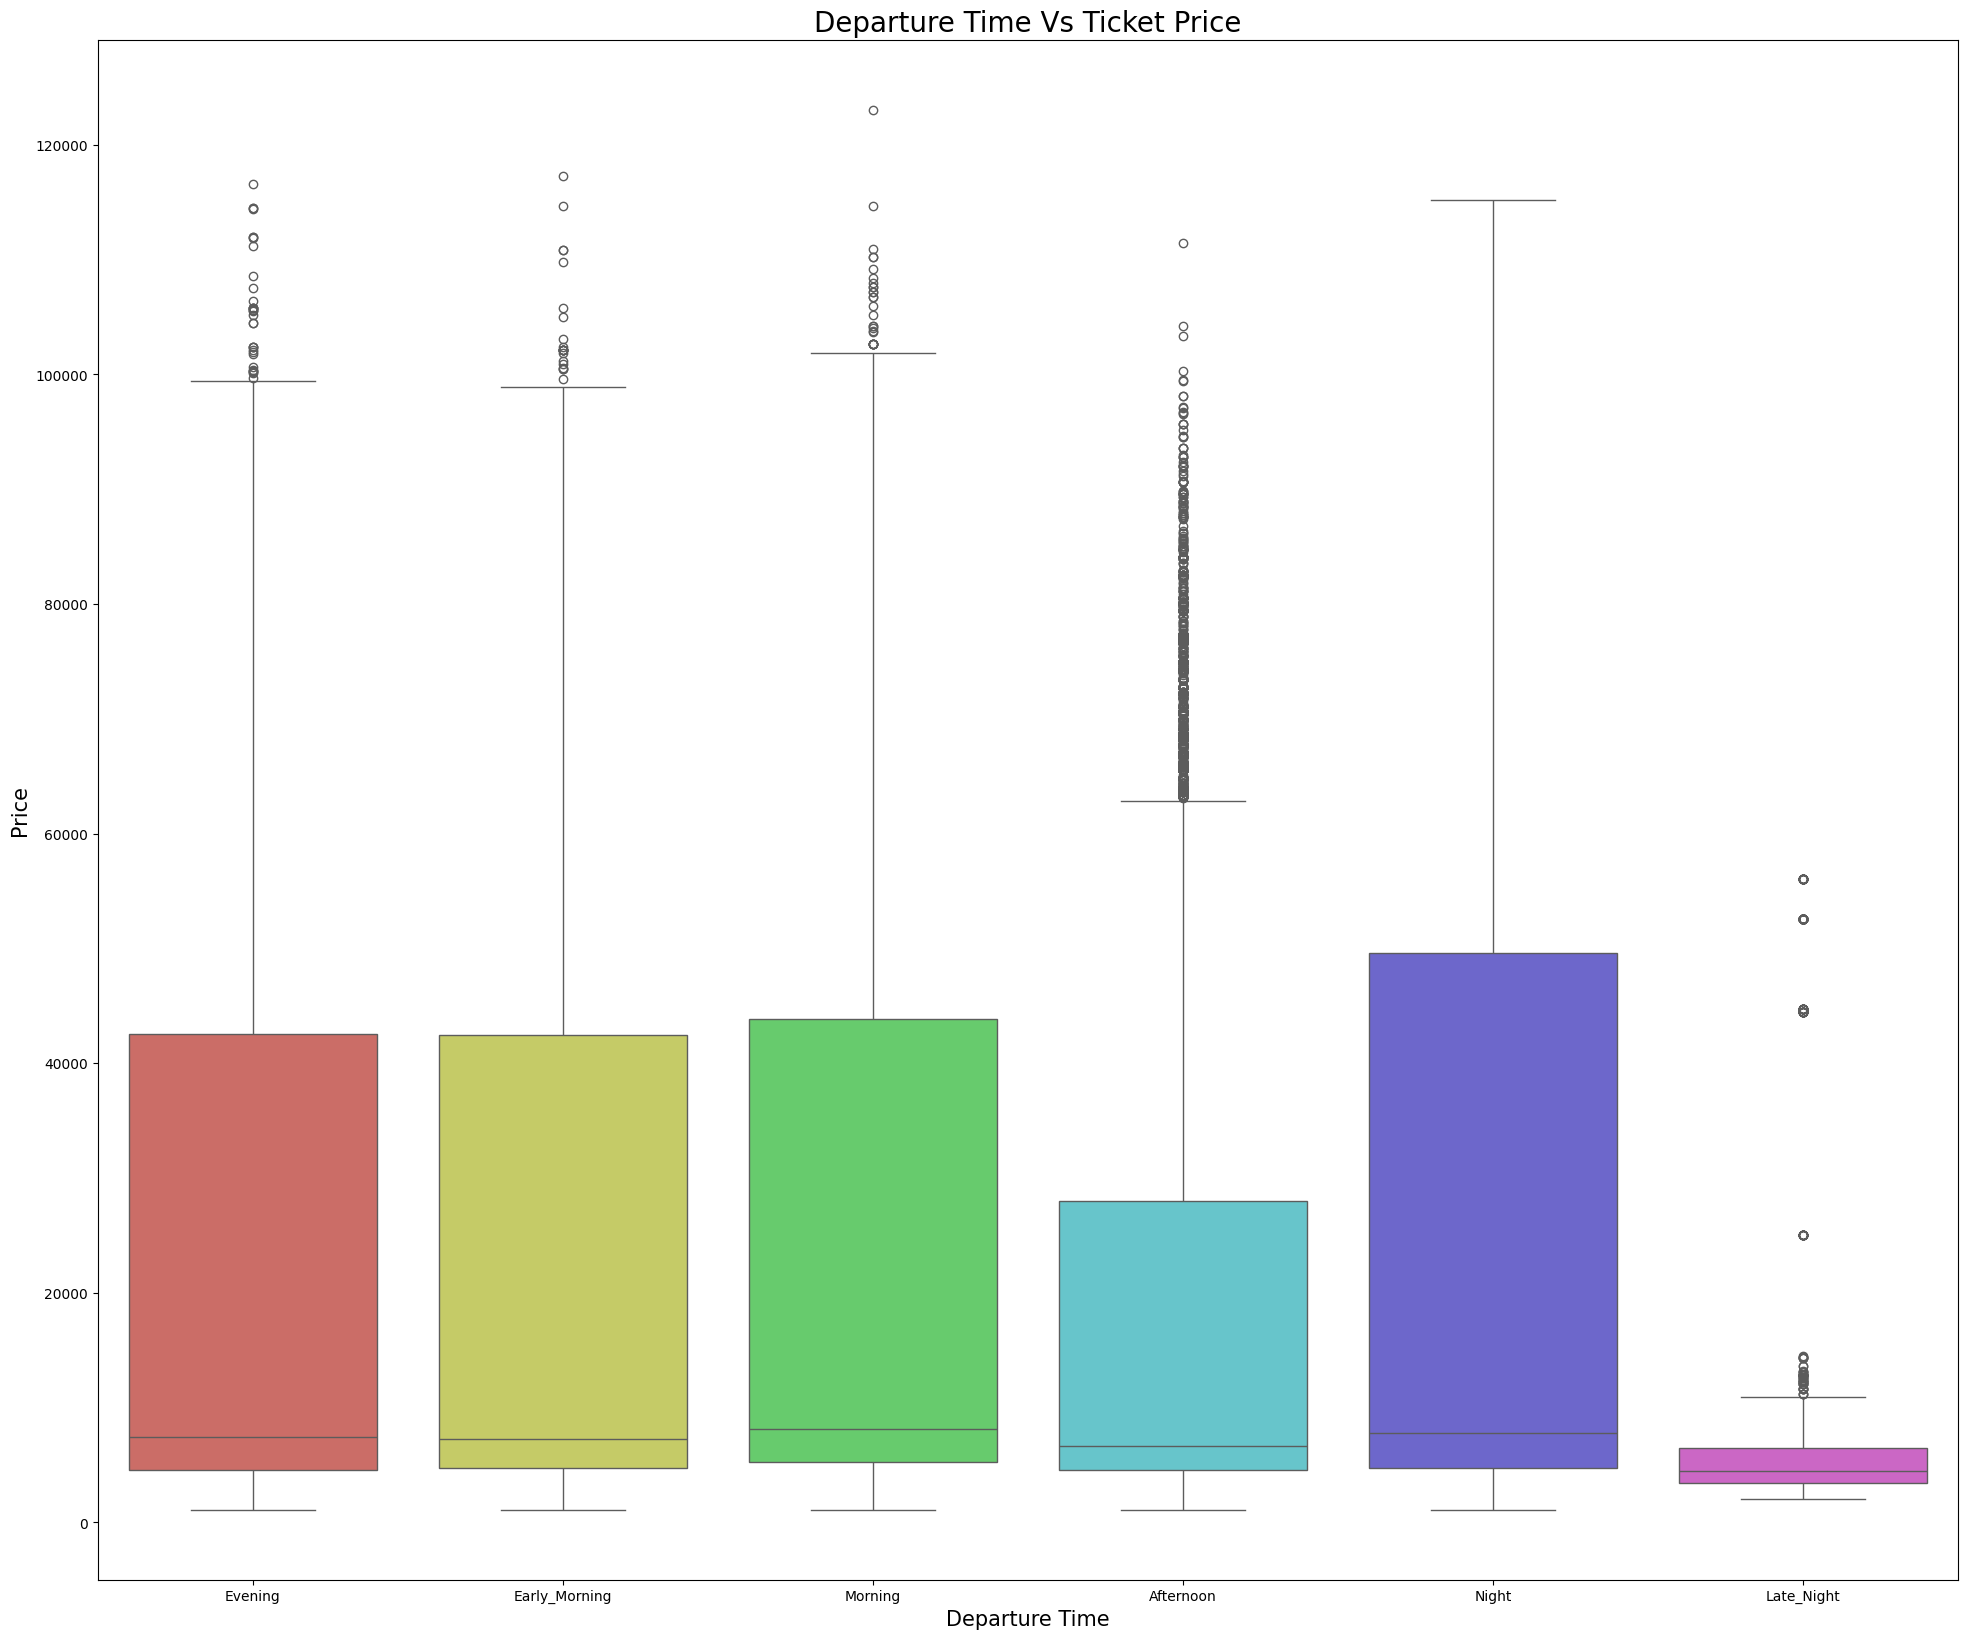

In [14]:
plt.figure(figsize=(24,20))
sns.boxplot(x='departure_time',y='price',data=df, palette='hls')
plt.title('Departure Time Vs Ticket Price',fontsize=20)
plt.xlabel('Departure Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

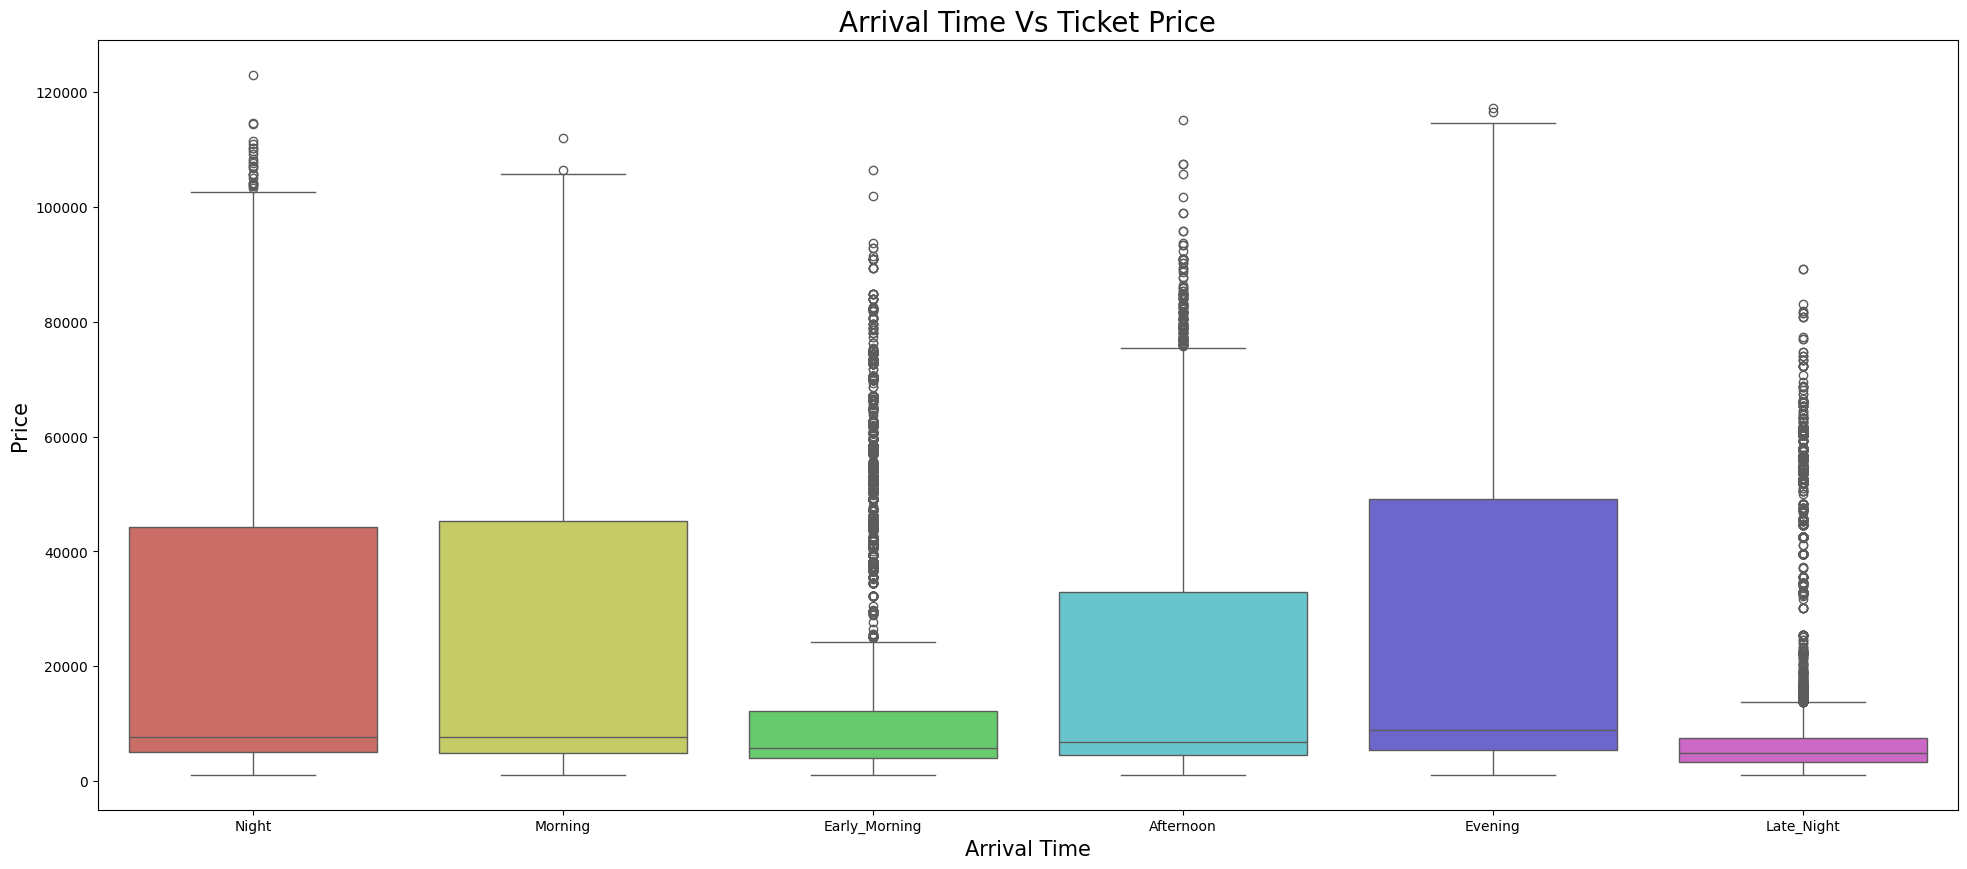

In [15]:
plt.figure(figsize=(24,10))
sns.boxplot(x='arrival_time',y='price',data=df,palette='hls')
plt.title('Arrival Time Vs Ticket Price',fontsize=20)
plt.xlabel('Arrival Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

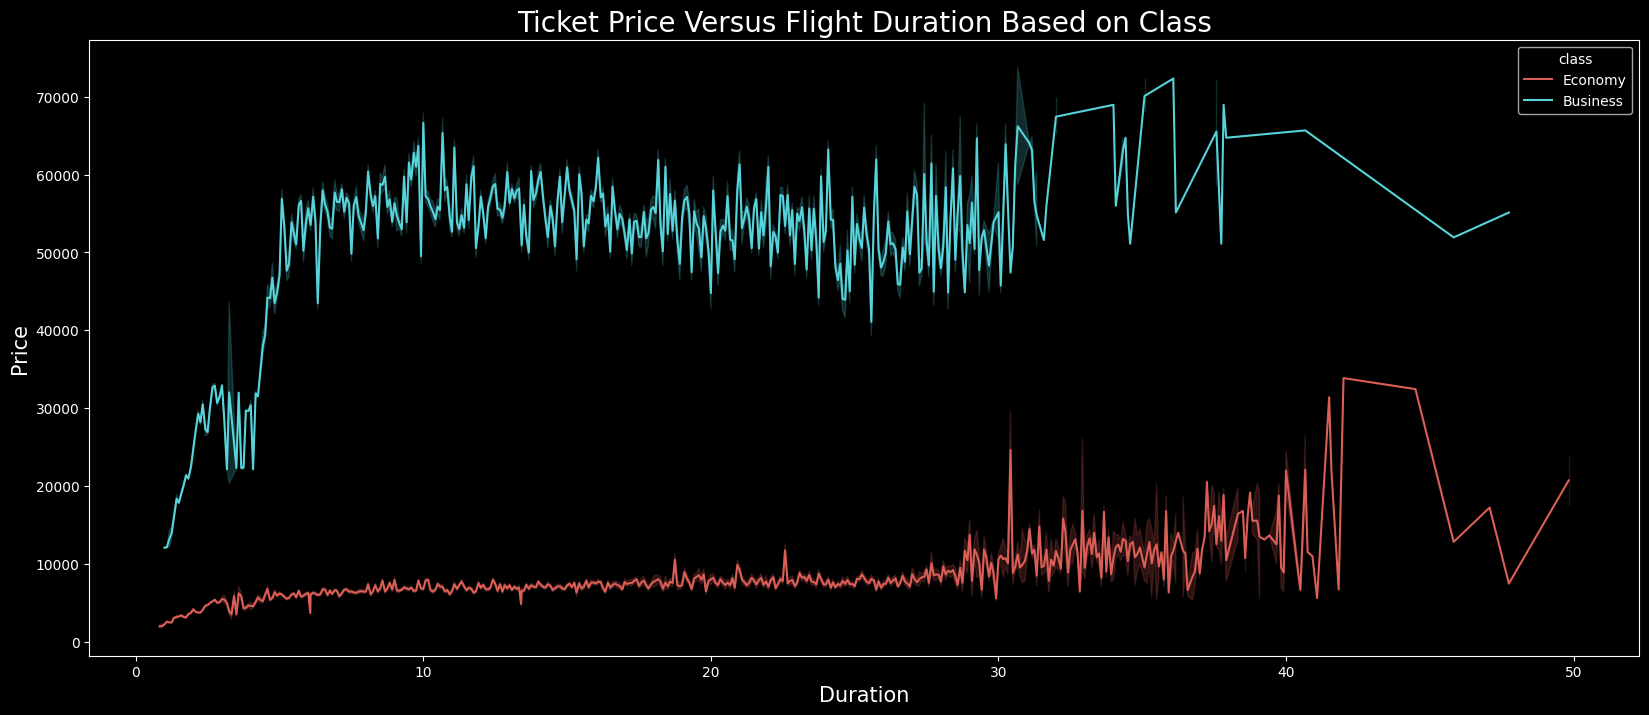

In [16]:
plt.style.use('dark_background')
plt.figure(figsize=(20,8))
sns.lineplot(data=df,x='duration',y='price',hue='class',palette='hls')
plt.title('Ticket Price Versus Flight Duration Based on Class',fontsize=20)
plt.xlabel('Duration',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

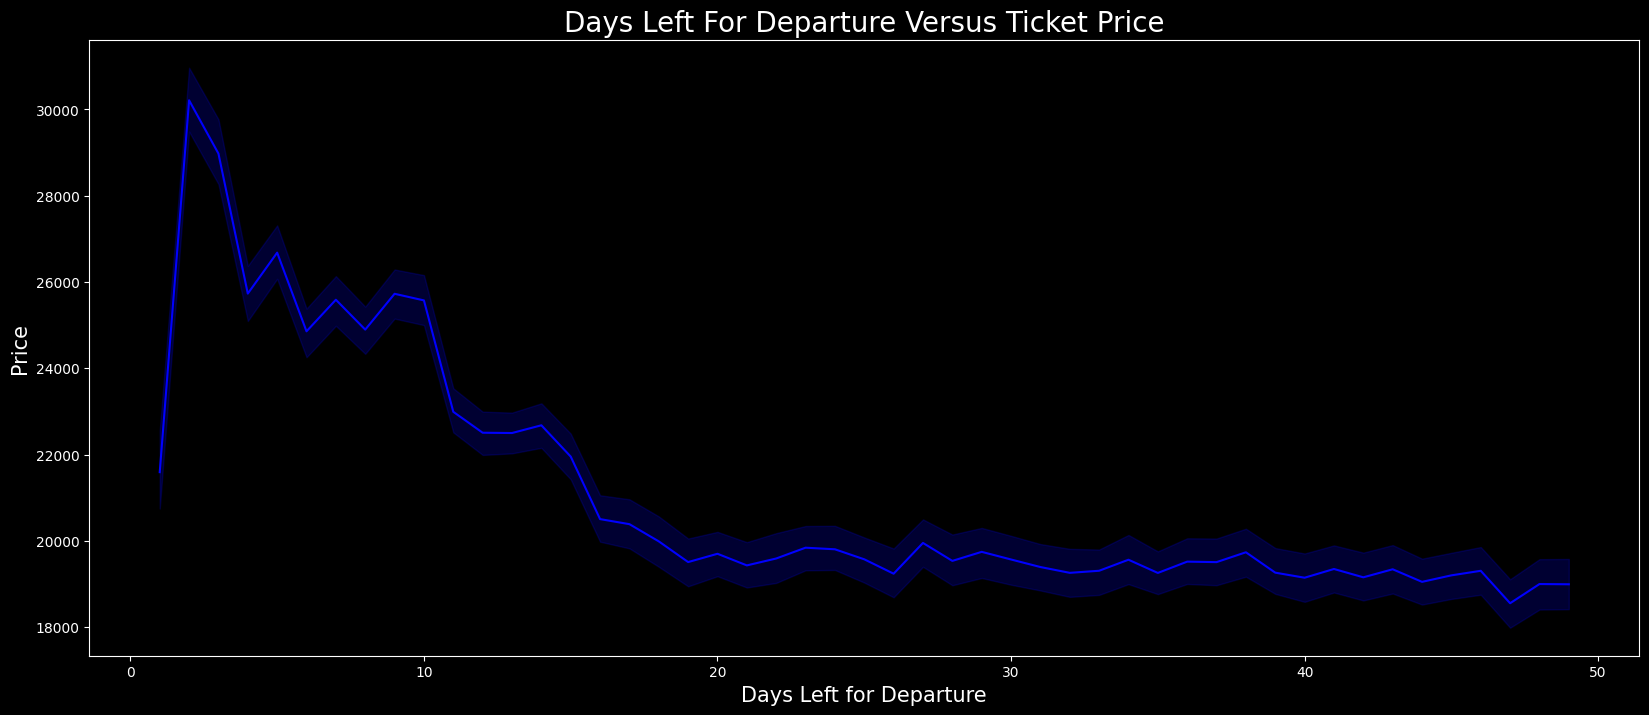

In [17]:
plt.figure(figsize=(20,8))
sns.lineplot(data=df,x='days_left',y='price',color='blue')
plt.title('Days Left For Departure Versus Ticket Price',fontsize=20)
plt.xlabel('Days Left for Departure',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

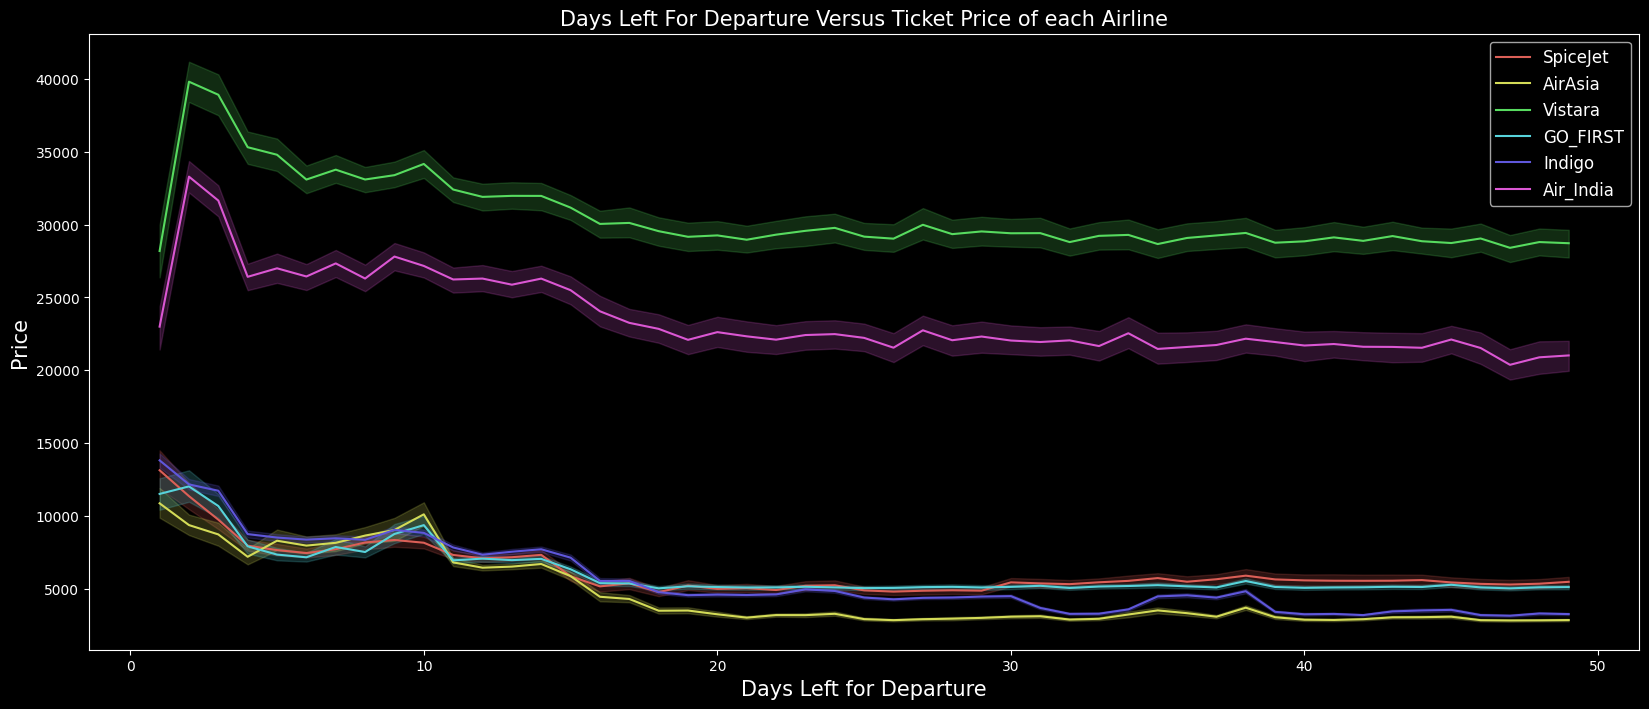

In [18]:
plt.figure(figsize=(20,8))
sns.lineplot(data=df,x='days_left',y='price',color='blue',hue='airline',palette='hls')
plt.title('Days Left For Departure Versus Ticket Price of each Airline',fontsize=15)
plt.legend(fontsize=12)
plt.xlabel('Days Left for Departure',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

In [19]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Modelos Nivel 1
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Modelos Nivel 2
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# Modelos Nivel 3
from sklearn.neural_network import MLPClassifier
# Importaremos Keras/TensorFlow si decidimos usar la red neuronal avanzada

# Ignoramos advertencias para mantener limpio el notebook
import warnings
warnings.filterwarnings('ignore')

In [20]:
# --- PASO 1: INGENIERÍA DE CARACTERÍSTICAS ---

# El objetivo es crear la columna 'bajara_precio'
# 1 = SÍ bajará, 0 = NO bajará (es el mejor precio actual)

print("Iniciando Ingeniería de Características...")

# Hacemos una copia para evitar advertencias de SettingWithCopyWarning
df_model = df.copy()

# 1. Encontrar el precio mínimo futuro para cada grupo
# Un "grupo" es la misma ruta (origen-destino), aerolínea y clase
group_cols = ['airline', 'source_city', 'destination_city', 'class']
df_model['precio_minimo_futuro'] = df_model.groupby(group_cols)['price'].transform('min')

# 2. Crear la variable objetivo 'bajara_precio'
# Si el precio actual es MAYOR que el precio mínimo futuro, significa que bajará (1)
# Si es igual (o menor, aunque no debería pasar), es el mejor precio (0)
df_model['bajara_precio'] = (df_model['price'] > df_model['precio_minimo_futuro']).astype(int)

# 3. Limpieza final antes de preprocesar
# Eliminamos las columnas que ya no necesitamos
df_model = df_model.drop(['flight', 'price', 'precio_minimo_futuro'], axis=1)

print("Ingeniería de Características completada.")
print("\nDistribución de la variable objetivo:")
print(df_model['bajara_precio'].value_counts(normalize=True) * 100)

print("\nVista previa de los datos listos para el modelo:")
print(df_model.head())

Iniciando Ingeniería de Características...
Ingeniería de Características completada.

Distribución de la variable objetivo:
bajara_precio
1    88.39292
0    11.60708
Name: proportion, dtype: float64

Vista previa de los datos listos para el modelo:
    airline source_city departure_time stops   arrival_time destination_city  \
0  SpiceJet       Delhi        Evening  zero          Night           Mumbai   
1  SpiceJet       Delhi  Early_Morning  zero        Morning           Mumbai   
2   AirAsia       Delhi  Early_Morning  zero  Early_Morning           Mumbai   
3   Vistara       Delhi        Morning  zero      Afternoon           Mumbai   
4   Vistara       Delhi        Morning  zero        Morning           Mumbai   

     class  duration  days_left  bajara_precio  
0  Economy      2.17          1              1  
1  Economy      2.33          1              1  
2  Economy      2.17          1              1  
3  Economy      2.25          1              1  
4  Economy      2.33     

In [26]:
# --- PASO 2: PREPROCESAMIENTO Y PIPELINES (Corregido) ---

# 1. Separar los datos en características (X) y objetivo (y)
X = df_model.drop('bajara_precio', axis=1)
y = df_model['bajara_precio']

# 2. Identificar las columnas numéricas y categóricas
numeric_features = ['duration', 'days_left']
categorical_features = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']
ordinal_features = ['stops']

# 3. Definir el orden para las escalas (stops)
stop_categories = ['zero', 'one', 'two_or_more']

# 4. Crear los transformadores para el Pipeline
# Pipeline para variables numéricas
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas ordinales (stops)
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[stop_categories]))
])

# Pipeline para variables categóricas nominales (el resto)
# ----- ESTA ES LA LÍNEA CORREGIDA -----
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
# -------------------------------------

# 5. Combinar los transformadores en un único Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras")

Datos de entrenamiento: 240122 muestras
Datos de prueba: 60031 muestras


In [27]:
# --- NIVEL 1: MODELOS LINEALES (Temario T2) ---

# 1. REGRESIÓN LOGÍSTICA (Clasificador Discriminativo)
print("--- Entrenando Regresión Logística ---")
log_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

# Entrenar el modelo
log_reg_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_proba_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1] # Probabilidad de que baje (clase 1)

# Evaluar el modelo
print("Resultados de la Regresión Logística:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log_reg):.4f}")
print(classification_report(y_test, y_pred_log_reg))
print("-" * 30)

--- Entrenando Regresión Logística ---
Resultados de la Regresión Logística:
Accuracy: 0.8886
ROC-AUC: 0.8509
              precision    recall  f1-score   support

           0       0.56      0.18      0.28      6947
           1       0.90      0.98      0.94     53084

    accuracy                           0.89     60031
   macro avg       0.73      0.58      0.61     60031
weighted avg       0.86      0.89      0.86     60031

------------------------------


In [28]:
# 2. ANÁLISIS DISCRIMINANTE LINEAL (LDA) (Clasificador Generativo)
print("--- Entrenando Análisis Discriminante Lineal (LDA) ---")

# Ahora el preprocesador genera datos densos, por lo que LDA funcionará correctamente.
lda_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', LinearDiscriminantAnalysis(solver='svd'))])

# Entrenar el modelo
lda_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_lda = lda_pipeline.predict(X_test)
y_proba_lda = lda_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo
print("Resultados de LDA:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lda):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lda):.4f}")
print(classification_report(y_test, y_pred_lda))
print("-" * 30)

--- Entrenando Análisis Discriminante Lineal (LDA) ---
Resultados de LDA:
Accuracy: 0.8875
ROC-AUC: 0.8518
              precision    recall  f1-score   support

           0       0.53      0.28      0.37      6947
           1       0.91      0.97      0.94     53084

    accuracy                           0.89     60031
   macro avg       0.72      0.63      0.65     60031
weighted avg       0.87      0.89      0.87     60031

------------------------------


In [29]:
# --- NIVEL 2: MODELOS NO PARAMÉTRICOS (Temario T5) ---

# Importaciones específicas para estos modelos (si no las has ejecutado)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 3. ÁRBOL DE DECISIÓN (DecisionTreeClassifier)
print("--- Entrenando Árbol de Decisión ---")

# Creamos el pipeline
tree_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', DecisionTreeClassifier(random_state=42))])

# --- Validación Cruzada ---
print("Iniciando validación cruzada (CV=3)...")
cv_scores_tree = cross_val_score(tree_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_tree}")
print(f"ROC-AUC Media (CV): {cv_scores_tree.mean():.4f} (+/- {cv_scores_tree.std():.4f})")
print("-" * 30)

# --- Entrenamiento final y Prueba ---
print("Entrenando modelo de Árbol final en todos los datos de train...")
tree_pipeline.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_tree = tree_pipeline.predict(X_test)
y_proba_tree = tree_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo final
print("\nResultados del Árbol de Decisión en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tree):.4f}")
print(classification_report(y_test, y_pred_tree))
print("-" * 30)

--- Entrenando Árbol de Decisión ---
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.93827004 0.93831133 0.93658291]
ROC-AUC Media (CV): 0.9377 (+/- 0.0008)
------------------------------
Entrenando modelo de Árbol final en todos los datos de train...

Resultados del Árbol de Decisión en el conjunto de Prueba:
Accuracy: 0.9744
ROC-AUC: 0.9387
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      6947
           1       0.99      0.99      0.99     53084

    accuracy                           0.97     60031
   macro avg       0.94      0.94      0.94     60031
weighted avg       0.97      0.97      0.97     60031

------------------------------


In [30]:
# --- 4. MODELOS DE ENSAMBLAJE (Temario T5) ---

# a. RANDOM FOREST (BAGGGING)
print("--- Entrenando Random Forest ---")

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))])

# --- Validación Cruzada ---
print("Iniciando validación cruzada (CV=3)...")
cv_scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_rf}")
print(f"ROC-AUC Media (CV): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")
print("-" * 30)

# --- Entrenamiento final y Prueba ---
print("Entrenando modelo Random Forest final en todos los datos de train...")
rf_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo final
print("\nResultados del Random Forest en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(classification_report(y_test, y_pred_rf))
print("-" * 30)

--- Entrenando Random Forest ---
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.99257246 0.99243464 0.99292223]
ROC-AUC Media (CV): 0.9926 (+/- 0.0002)
------------------------------
Entrenando modelo Random Forest final en todos los datos de train...

Resultados del Random Forest en el conjunto de Prueba:
Accuracy: 0.9744
ROC-AUC: 0.9926
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      6947
           1       0.99      0.99      0.99     53084

    accuracy                           0.97     60031
   macro avg       0.94      0.94      0.94     60031
weighted avg       0.97      0.97      0.97     60031

------------------------------


In [32]:
# b. LIGHTGBM (GRADIENT BOOSTING) - CORREGIDO
print("--- Entrenando LightGBM (Versión Corregida) ---")

# Para que LightGBM maneje categóricas dentro de un pipeline de scikit-learn,
# primero debemos convertirlas a enteros (ej. con OrdinalEncoder).
# Luego, le decimos a LGBM cuáles son esas columnas "categóricas" (basado en sus índices).

# 1. Nuevas listas de columnas
numeric_features = ['duration', 'days_left']

# 'stops' ya es ordinal
ordinal_features = ['stops']
stop_categories = ['zero', 'one', 'two_or_more']

# Estas son las que también codificaremos como ordinales para LGBM
categorical_features_lgbm = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']

# 2. Creamos un OrdinalEncoder para las categóricas
# handle_unknown='use_encoded_value', unknown_value=-1 es importante
# por si aparece una categoría nueva en los datos de prueba.
categorical_transformer_lgbm = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
ordinal_transformer_stops = Pipeline(steps=[('ordinal', OrdinalEncoder(categories=[stop_categories]))])


# 3. Preprocesador Específico para LGBM
# Todos los tipos de columnas ahora pasan por un transformador
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),           # 2 columnas (índice 0, 1)
        ('ord_stops', ordinal_transformer_stops, ordinal_features), # 1 columna (índice 2)
        ('cat', categorical_transformer_lgbm, categorical_features_lgbm) # 6 columnas (índice 3-8)
    ],
    remainder='drop'
)

# 4. Lista de índices de todas las columnas categóricas (stops + el resto)
# Índices 2 (stops) + 3, 4, 5, 6, 7, 8 (el resto)
# (El número total de columnas que verá el clasificador es 2 num + 1 ord + 6 cat = 9)
categorical_indices_lgbm = [2] + list(range(len(numeric_features) + len(ordinal_features), 
                                            len(numeric_features) + len(ordinal_features) + len(categorical_features_lgbm)))

print(f"Índices de columnas categóricas para LGBM: {categorical_indices_lgbm}")


# 5. Crear el Pipeline de LightGBM
# Ahora pasamos los índices categóricos en el constructor
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('classifier', LGBMClassifier(random_state=42, n_jobs=-1, 
                                  categorical_feature=categorical_indices_lgbm))
])

# --- Validación Cruzada (Ahora funcionará sin 'fit_params') ---
print("Iniciando validación cruzada (CV=3)...")

cv_scores_lgbm = cross_val_score(lgbm_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)

print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_lgbm}")
print(f"ROC-AUC Media (CV): {cv_scores_lgbm.mean():.4f} (+/- {cv_scores_lgbm.std():.4f})")
print("-" * 30)

# --- Entrenamiento final y Prueba ---
print("Entrenando modelo LightGBM final en todos los datos de train...")

# Ya no necesitamos **fit_params**
lgbm_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_lgbm = lgbm_pipeline.predict(X_test)
y_proba_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo final
print("\nResultados de LightGBM en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm))
print("-" * 30)

--- Entrenando LightGBM (Versión Corregida) ---
Índices de columnas categóricas para LGBM: [2, 3, 4, 5, 6, 7, 8]
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.98367015 0.98392884 0.98397017]
ROC-AUC Media (CV): 0.9839 (+/- 0.0001)
------------------------------
Entrenando modelo LightGBM final en todos los datos de train...
[LightGBM] [Info] Number of positive: 212230, number of negative: 27892
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 346
[LightGBM] [Info] Number of data points in the train set: 240122, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.883842 -> initscore=2.029331
[LightGBM] [Info] Start training from score 2.029331

Resultados de LightGBM en el conjunto de Prueba:
Accuracy: 0.9547
ROC-AUC: 0.

In [33]:
# --- Guardamos los resultados de los niveles 1 y 2 ---

# Inicializamos el diccionario de resultados
model_results = {
    'Regresión Logística': {
        'roc_auc': roc_auc_score(y_test, y_proba_log_reg),
        'accuracy': accuracy_score(y_test, y_pred_log_reg)
    },
    'LDA': {
        'roc_auc': roc_auc_score(y_test, y_proba_lda),
        'accuracy': accuracy_score(y_test, y_pred_lda)
    },
    'Árbol de Decisión': {
        'roc_auc': roc_auc_score(y_test, y_proba_tree),
        'accuracy': accuracy_score(y_test, y_pred_tree)
    },
    'Random Forest': {
        'roc_auc': roc_auc_score(y_test, y_proba_rf),
        'accuracy': accuracy_score(y_test, y_pred_rf)
    },
    'LightGBM': {
        'roc_auc': roc_auc_score(y_test, y_proba_lgbm),
        'accuracy': accuracy_score(y_test, y_pred_lgbm)
    }
}

print("Resultados de los modelos anteriores guardados.")

Resultados de los modelos anteriores guardados.


In [35]:
%pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
    --------------------------------------- 4.5/332.0 MB 24.7 MB/s eta 0:00:14
   - -------------------------------------- 9.7/332.0 MB 24.7 MB/s eta 0:00:14
   - -------------------------------------- 14.7/332.0 MB 24.5 MB/s eta 0:00:13
   -- ------------------------------------- 16.8/332.0 MB 24.1 MB/s eta 0:00:14
   -- ------------------------------------- 16.8/332.0 MB 24.1 MB/s eta 0:00:14
   -- ------------------------------------- 17.6/332.0 MB 14.3 MB/s eta 0:00:22
   -- ------------------------------------- 21.8/332.0 MB 15.3 MB/s eta 0:00:21
   --- ------------------------------------ 26.5/332.0 MB 16.2 MB/s eta 0:00:19
   --- ------------------------------------ 32.5/332.0 MB 17.6 MB/s eta 0:00:17
   ---- ----------------------------------- 38.5/332.0 MB 18.8 MB/s eta 0:00:16
   ----- ---------------------------------- 44.6/332.0 MB 19.7 MB/s eta 0:00:15
   ----- ---------------------------------- 49.0/33


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
%pip install keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
# --- NIVEL 3: REDES NEURONALES (Temario T3 y T4) ---

# Importamos las librerías necesarias para este nivel
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 5. REDES NEURONALES 1 (MLPClassifier - Temario T3)
print("--- Entrenando Perceptrón Multicapa (MLP) ---")

# Creamos el pipeline con el preprocesador y el clasificador MLP
mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Usamos el preprocesador original con OneHotEncoder
    ('classifier', MLPClassifier(hidden_layer_sizes=(64, 64),
                                 activation='relu',
                                 solver='adam',
                                 max_iter=500,
                                 random_state=42,
                                 early_stopping=True, # Para evitar sobreajuste
                                 n_iter_no_change=10))
])

# --- Validación Cruzada ---
print("Iniciando validación cruzada (CV=3)...")
cv_scores_mlp = cross_val_score(mlp_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_mlp}")
print(f"ROC-AUC Media (CV): {cv_scores_mlp.mean():.4f} (+/- {cv_scores_mlp.std():.4f})")
print("-" * 30)

# --- Entrenamiento final y Prueba ---
print("Entrenando modelo MLP final en todos los datos de train...")
mlp_pipeline.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_mlp = mlp_pipeline.predict(X_test)
y_proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo final
print("\nResultados del MLP en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))
print("-" * 30)

# Guardamos los resultados
model_results['MLP (Scikit-learn)'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_mlp),
    'accuracy': accuracy_score(y_test, y_pred_mlp)
}

--- Entrenando Perceptrón Multicapa (MLP) ---
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.98781691 0.98807395 0.98720315]
ROC-AUC Media (CV): 0.9877 (+/- 0.0004)
------------------------------
Entrenando modelo MLP final en todos los datos de train...

Resultados del MLP en el conjunto de Prueba:
Accuracy: 0.9573
ROC-AUC: 0.9870
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      6947
           1       0.97      0.98      0.98     53084

    accuracy                           0.96     60031
   macro avg       0.90      0.89      0.89     60031
weighted avg       0.96      0.96      0.96     60031

------------------------------


In [37]:
# --- 6. REDES NEURONALES 2 (DNN con Keras - Temario T4) ---

# Fijamos una semilla para que los resultados de la red neuronal sean reproducibles
tf.random.set_seed(42)

print("--- Preparando datos para Keras ---")

# 1. Aplicar el preprocesamiento manualmente
# Usamos el preprocesador original ('preprocessor') con OneHotEncoder
# que ya estaba ajustado a los datos de entrenamiento
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 2. Crear un conjunto de validación desde el conjunto de entrenamiento
# Esto es crucial para monitorizar el entrenamiento de la red
# Usamos el 20% de los datos de entrenamiento para validación
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=42
)

print(f"Forma de X_train_nn: {X_train_nn.shape}")
print(f"Forma de X_val_nn: {X_val_nn.shape}")
print(f"Forma de X_test_processed: {X_test_processed.shape}")

--- Preparando datos para Keras ---
Forma de X_train_nn: (192097, 35)
Forma de X_val_nn: (48025, 35)
Forma de X_test_processed: (60031, 35)


In [38]:
# --- 6. (Continuación) Definición y Entrenamiento del Modelo DNN ---

print("\n--- Construyendo y Entrenando la Red Neuronal Profunda (DNN) ---")

# Definimos la arquitectura de la red (más profunda, como en T4)
model_dnn = keras.Sequential([
    # Capa de entrada (shape basada en las columnas preprocesadas)
    layers.Input(shape=(X_train_nn.shape[1],)),
    
    # 1ª Capa Oculta
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Técnica de regularización para evitar sobreajuste
    
    # 2ª Capa Oculta
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    # 3ª Capa Oculta (¡Más profunda!)
    layers.Dense(32, activation='relu'),
    
    # Capa de Salida
    # Usamos 'sigmoid' porque es un problema de clasificación binaria (0 o 1) [cite: 1712, 1761]
    layers.Dense(1, activation='sigmoid')
])

# Compilamos el modelo
model_dnn.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Pérdida estándar para clasificación binaria
    metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')] # Monitorizamos accuracy y ROC-AUC
)

# Resumen de la arquitectura
model_dnn.summary()

# Callback para parar el entrenamiento si no mejora (EarlyStopping)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_roc_auc', # Monitorizamos el ROC-AUC en el set de validación
    patience=10,           # Número de épocas sin mejora antes de parar
    mode='max',            # Queremos maximizar el ROC-AUC
    restore_best_weights=True # Nos quedamos con los pesos del mejor modelo
)

# Entrenar el modelo
history = model_dnn.fit(
    X_train_nn,
    y_train_nn,
    epochs=100, # Un número alto, EarlyStopping se encargará de parar
    batch_size=128,
    validation_data=(X_val_nn, y_val_nn),
    callbacks=[early_stopping],
    verbose=1
)


--- Construyendo y Entrenando la Red Neuronal Profunda (DNN) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9123 - loss: 0.2047 - roc_auc: 0.9243 - val_accuracy: 0.9332 - val_loss: 0.1508 - val_roc_auc: 0.9616
Epoch 2/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9318 - loss: 0.1552 - roc_auc: 0.9597 - val_accuracy: 0.9427 - val_loss: 0.1308 - val_roc_auc: 0.9713
Epoch 3/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9379 - loss: 0.1389 - roc_auc: 0.9683 - val_accuracy: 0.9480 - val_loss: 0.1189 - val_roc_auc: 0.9766
Epoch 4/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9408 - loss: 0.1301 - roc_auc: 0.9725 - val_accuracy: 0.9499 - val_loss: 0.1124 - val_roc_auc: 0.9794
Epoch 5/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9436 - loss: 0.1241 - roc_auc: 0.9750 - val_accuracy: 0.9504 - val_loss: 0.1086 - val_roc_auc: 0.9806
Epoch 6/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9448 - loss: 0.1197 - roc_auc: 0.9767 - val_accuracy: 0.9520 - val_loss: 0.1

In [39]:
# --- 6. (Continuación) Evaluación del Modelo DNN ---

print("\n--- Evaluación de la Red Neuronal Profunda (DNN) ---")

# Evaluar el modelo final en el conjunto de prueba
loss_dnn, accuracy_dnn, roc_auc_dnn = model_dnn.evaluate(X_test_processed, y_test, verbose=0)

# Obtener las predicciones de probabilidad
y_proba_dnn = model_dnn.predict(X_test_processed).ravel()
# Convertir probabilidades a clases (0 o 1)
y_pred_dnn = (y_proba_dnn > 0.5).astype(int)

print(f"Resultados de la DNN en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_dnn:.4f}")
print(f"ROC-AUC: {roc_auc_dnn:.4f}")
print(classification_report(y_test, y_pred_dnn))
print("-" * 30)

# Guardamos los resultados
model_results['DNN (Keras)'] = {
    'roc_auc': roc_auc_dnn,
    'accuracy': accuracy_dnn
}

print("Resultados de todos los modelos guardados.")


--- Evaluación de la Red Neuronal Profunda (DNN) ---
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 1s 651us/step
Resultados de la DNN en el conjunto de Prueba:
Accuracy: 0.9585
ROC-AUC: 0.9869
              precision    recall  f1-score   support

           0       0.85      0.78      0.81      6947
           1       0.97      0.98      0.98     53084

    accuracy                           0.96     60031
   macro avg       0.91      0.88      0.90     60031
weighted avg       0.96      0.96      0.96     60031

------------------------------
Resultados de todos los modelos guardados.


--- Tabla Comparativa de Rendimiento de Modelos ---
|                          |   roc_auc |   accuracy |
|:-------------------------|----------:|-----------:|
| Random Forest (T5)       |    0.9926 |     0.9744 |
| MLP (Scikit-learn) (T3)  |    0.9870 |     0.9573 |
| DNN (Keras) (T4)         |    0.9869 |     0.9585 |
| LightGBM (T5)            |    0.9824 |     0.9547 |
| Árbol de Decisión (T5)   |    0.9387 |     0.9744 |
| LDA (T2)                 |    0.8518 |     0.8875 |
| Regresión Logística (T2) |    0.8509 |     0.8886 |


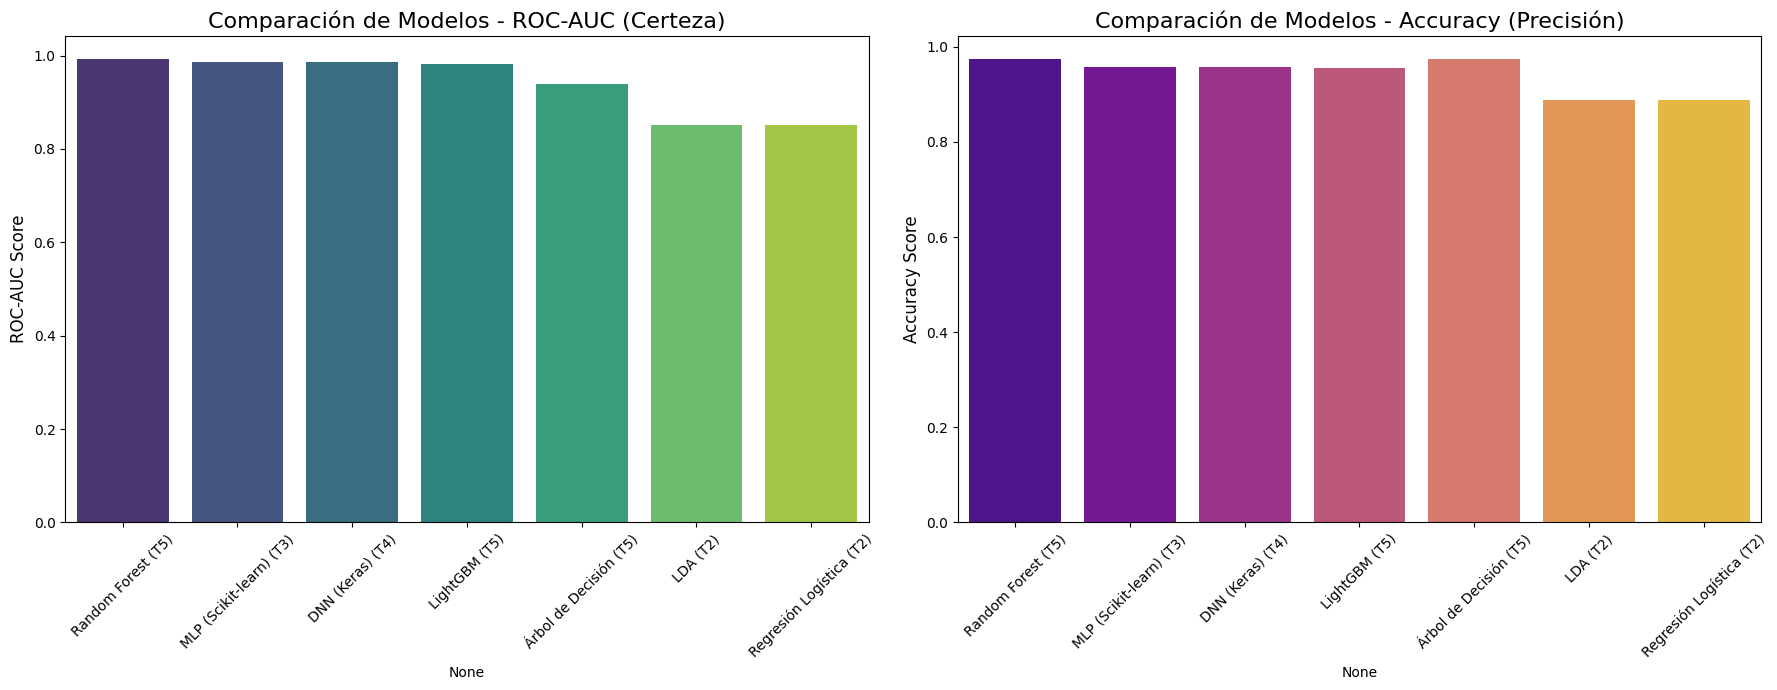

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- RECOPILACIÓN DE TODOS LOS RESULTADOS ---

# (Asegúrate de haber ejecutado las celdas anteriores para que todas las variables 
# como 'roc_auc_log_reg', 'roc_auc_lda', 'accuracy_dnn', etc., estén definidas)

# Re-creamos el diccionario con todos los resultados finales de las pruebas
model_results = {
    'Regresión Logística (T2)': {
        'roc_auc': roc_auc_score(y_test, y_proba_log_reg),
        'accuracy': accuracy_score(y_test, y_pred_log_reg)
    },
    'LDA (T2)': {
        'roc_auc': roc_auc_score(y_test, y_proba_lda),
        'accuracy': accuracy_score(y_test, y_pred_lda)
    },
    'Árbol de Decisión (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_tree),
        'accuracy': accuracy_score(y_test, y_pred_tree)
    },
    'Random Forest (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_rf),
        'accuracy': accuracy_score(y_test, y_pred_rf)
    },
    'LightGBM (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_lgbm),
        'accuracy': accuracy_score(y_test, y_pred_lgbm)
    },
    'MLP (Scikit-learn) (T3)': {
        'roc_auc': roc_auc_score(y_test, y_proba_mlp),
        'accuracy': accuracy_score(y_test, y_pred_mlp)
    },
    'DNN (Keras) (T4)': {
        'roc_auc': roc_auc_dnn,
        'accuracy': accuracy_dnn
    }
}

# Convertimos el diccionario a un DataFrame de Pandas para una fácil visualización
results_df = pd.DataFrame.from_dict(model_results, orient='index')

# Ordenamos los modelos por ROC-AUC (nuestra métrica de "certeza") de mayor a menor
results_df.sort_values(by='roc_auc', ascending=False, inplace=True)

# Mostramos los resultados
print("--- Tabla Comparativa de Rendimiento de Modelos ---")
print(results_df.to_markdown(floatfmt=".4f"))

# --- Visualización de Resultados ---
plt.style.use('default') # Volvemos al estilo por defecto para los gráficos
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de ROC-AUC
sns.barplot(x=results_df.index, y=results_df['roc_auc'], ax=ax[0], palette='viridis')
ax[0].set_title('Comparación de Modelos - ROC-AUC (Certeza)', fontsize=16)
ax[0].set_ylabel('ROC-AUC Score', fontsize=12)
ax[0].tick_params(axis='x', rotation=45)

# Gráfico de Accuracy
sns.barplot(x=results_df.index, y=results_df['accuracy'], ax=ax[1], palette='plasma')
ax[1].set_title('Comparación de Modelos - Accuracy (Precisión)', fontsize=16)
ax[1].set_ylabel('Accuracy Score', fontsize=12)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# (Este es un ejemplo, no es necesario que lo ejecutes ahora)

# 1. El usuario introduce sus datos
datos_usuario = pd.DataFrame({
    'airline': ['Vistara'],
    'source_city': ['Delhi'],
    'departure_time': ['Evening'],
    'stops': ['one'],
    'arrival_time': ['Night'],
    'destination_city': ['Mumbai'],
    'class': ['Economy'],
    'duration': [7.5],
    'days_left': [25]
})

probabilidad_bajada = lgbm_pipeline.predict_proba(datos_usuario)[0][1]
certeza = probabilidad_bajada * 100

# 3. Damos la recomendación
if certeza > 50:
    print(f"RECOMENDACIÓN: ESPERAR ✋")
    print(f"Hay un {certeza:.2f}% de certeza de que el precio bajará.")
else:
    print(f"RECOMENDACIÓN: COMPRAR AHORA ✅")
    print(f"Es poco probable que el precio baje (Certeza de bajada: {certeza:.2f}%)")

RECOMENDACIÓN: ESPERAR ✋
Hay un 99.35% de certeza de que el precio bajará.
